In [1]:
import warnings; warnings.simplefilter("ignore")

___



# Exercise "Data Analysis for Engineers" SS2026 - Data analysis & Forecasting</span>

___




---
# **1. Introduction**
---
Welcome to our exercise notebook on data analysis and time series forecasting with sktime! In this 2026 edition we additionally explore **foundation models** for time series — in particular **Chronos 2** by Amazon Science. This notebook will explore some tools for analyzing data and further show a small pipeline approach to forecast future values. This notebook will provide you with some insights and hands-on experience in working with time series data. Therefore, let's get started and dive into the exciting world of data analysis and time series forecasting!

Please note it is mandatory to install all the required software and packages using the guide provided in Ilias before proceeding with this exercise notebook. The guide contains important instructions on how to properly set up your environment. This ensures that all the necessary dependencies are installed. Failure to follow the instructions may result in errors or unexpected behavior while working through the notebook.

This is an interactive notebook and also includes some work assignments. Typical tasks are adding lines of code and documenting observations. Work orders are always marked in the color <span style="color:#A00000"> **red** </span>. We suggest you work in pairs or small groups so that you can share observations and discuss the tasks together.

___

## Agenda

1. Introduction, agenda, learning goals, and data loading

2. Data analysis

3. Forecasting exercise

4. Probabilistic forecasting

___

## Learning Goals (Sorted by Chapter)

### 📈 Data Analysis and Time Series Analysis

- Identify key properties of time series, such as **seasonality**, **trend**, and **autocorrelation**  
- Analyze energy-related time series and **detect**, **interpret**, and **evaluate** seasonal patterns  
- **Create and select** relevant calendar-based features using insights from seasonality and autocorrelation analysis

---

### 🤖 Machine Learning

- Understand the **core concepts** of the `sktime` library  
- Be familiar with **standard evaluation metrics** used in forecasting  
- **Evaluate forecasters**, interpret their errors, and **derive features** to improve model performance  
- Understand the **foundations of probabilistic forecasting** and its practical applications
- Apply **zero-shot foundation models** (e.g. **Chronos 2**) for time series forecasting

___
___


## ⚡ IEEE Case 9 — Data & AI in Energy Systems

![IEEE Case 9](case_9_excercise_dataanalysis.png)

The **IEEE 9-Bus Test Case** is a simplified power system model ideal for exploring how **AI** and **data analysis** can improve modern energy grid operations.

---

### 🔍 Why AI Matters in Energy

As energy systems grow more complex, **AI enables smarter, faster, and more adaptive solutions** — from predicting failures to optimizing power flow.

---

### 🤖 Core AI Applications in Power Systems

| Area                   | Description                                                                 |
|------------------------|-----------------------------------------------------------------------------|
| **Forecasting**        | Predict load, generation (e.g., wind/solar), or market prices to support planning and operations. |
| **Predictive Maintenance** | Detect early signs of equipment failure using historical and real-time sensor data. |
| **Optimal Power Flow (OPF)** | Use AI to find fast, near-optimal solutions for generation dispatch and voltage control. |
| **Scheduling & Dispatch**   | Apply AI (e.g. reinforcement learning) to automate generation scheduling under uncertainty. |
| **Anomaly Detection**  | Spot faults or abnormal patterns in grid behavior using unsupervised learning. |

---

In [2]:
#
# It is a try, but not a complete solution. A lot of messages are still in the notebook.
#

import logging
import warnings
import torch
import os

# Option 2: nach der Warning-Message filtern (zuverlässiger)
warnings.filterwarnings(
    "ignore",
    message=".*Downcasting object dtype arrays.*",
    category=FutureWarning,
)


logging.getLogger("pytorch_lightning").setLevel(logging.CRITICAL)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
# Pandas FutureWarning aus sktime
warnings.filterwarnings("ignore", category=FutureWarning, module="sktime")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

# Lightning-Tipp und Info-Meldungen
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

#
# Seeded for reproducibility that everyone gets the same results.
# 1) Suppress pandas FutureWarning from sktime adapter

warnings.filterwarnings("ignore", category=FutureWarning)


# 3) Suppress litmodels "💡 Tip" stdout print
os.environ["LITMODELS_DISABLE_TIPS"] = "1"

# Suppress pandas FutureWarning from sktime adapter
warnings.filterwarnings("ignore", category=FutureWarning)

# Suppress Lightning trainer logs (GPU info, LOCAL_RANK, etc.)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

# Suppress Lightning "💡 Tip" stdout print
os.environ["LITMODELS_DISABLE_TIPS"] = "1"

# Suppress Lightning progress bar output to stderr
os.environ["PYTORCH_LIGHTNING_LOGGING_LEVEL"] = "ERROR"

torch.manual_seed(0)

In [3]:
from helper_methods import (
    plot_forecasts_for_day,
    interactive_forecast_plot,
    plot_full_forecast_series,
    plot_full_forecast_series_prob,
    summarize_metrics,
    evaluate_chronos2_native,
    plot_hour_encodings_over_time,
    plot_holiday_encodings_over_time,
)

2026-06-09 11:24:51.789685: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 11:24:51.796816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780997091.804929 3629115 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780997091.807368 3629115 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780997091.813924 3629115 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [4]:
import certifi
import io
import ssl
import urllib.request
import pandas as pd

# The data is from the Open Power System Data project, which provides household electricity consumption data.
url = 'https://data.open-power-system-data.org/household_data/2020-04-15/household_data_60min_singleindex.csv'
ssl_context = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(url, context=ssl_context) as response:
    data = pd.read_csv(io.BytesIO(response.read()), date_format='%Y-%m-%dT%H:%M:%SZ', index_col='utc_timestamp', parse_dates=True, sep=',')

data.index = pd.to_datetime(data.index, utc=True)




## Data loading and first preprocessing
As a basis for the data analysis we need data in the first place. This publically available data set is described here: [Full Dataset Introduction](https://data.open-power-system-data.org/household_data/2020-04-15)

Here we have taken only a subset of the data, since we want to deal with only one building. Our choice is the industrial building 3. All the data is scaled in kWh. The building has an installed pv and an energy demand.



In [5]:
import statsmodels.api as sm
from matplotlib import pylab
from pylab import *


# Basic configuration to get beautiful pictures
pylab.rcParams['figure.figsize'] = (16, 9)

# Get the relevant data for this excercise and resample it to hourly resolution to save runtime complexity
data["demand"] = data["DE_KN_industrial3_grid_import"].diff(1)
data["solar"] = (data["DE_KN_industrial3_pv_facade"].diff(1) + data["DE_KN_industrial3_pv_roof"].diff(1))

# shift the index of the data by one interval to get the correct time alignment
data.index = data.index - pd.Timedelta(hours=1)

# Omit data without values
data = data[["demand","solar"]].dropna()
# Let the data start with a full day and end with a full day
data =  data[(data.index >= pd.to_datetime("2016-03-01",utc=True)) &  (data.index < pd.to_datetime("2017-05-01",utc=True))]
data = data.asfreq('1h')

---
# **2. Data Analysis**
---
<img src="https://imgs.xkcd.com/comics/data_trap.png" width="400" height="400">

[This xkcd comic you can find here](https://xkcd.com/2582/)

Within the data analysis chapter, we will first use simple tools from Pandas to get an overview of the data set.
After that, we will make a daily observation of the load and analyse the difference between a weekday and weekend.
In the last part we will use more complex tools like autocorellation plots and a seasonal decomposition to identify properties like trend and seasonality in our time series.

First of all, we would like to show you three very simple functions that Pandas has ready for you :

## Warmup and get familiar with the data

1. head() First five rows of the data set. Commonly used as a sanity check to see how the Data is constructed. [API](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
2. describe() Provides basic satistical values of the dataset. For example, mean, standard deviation and quantiles.[API](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)
3. plot() The plot function draws a simple plot over all collumns of the given dataset with mathplolib. [API](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)

### <span style="color:#A00000"> Use the three functions (head, describe and plot) below! </span>



In [6]:
# Use the head function

data.head()

,demand,solar
utc_timestamp,,
2016-03-01 00:00:00+00:00,62.00,0.0
2016-03-01 01:00:00+00:00,62.25,0.0
2016-03-01 02:00:00+00:00,61.75,0.0
2016-03-01 03:00:00+00:00,61.00,0.0
2016-03-01 04:00:00+00:00,61.25,0.0


In [7]:
# Use the describe function
data.describe()

,demand,solar
count,10224.000000,10224.000000
mean,79.369383,2.199932
std,32.268000,3.833016
min,28.750000,0.000000
25%,57.250000,0.000000
50%,61.750000,0.027000
75%,95.250000,2.721500
max,222.500000,17.156000


In [8]:
#TODO interactive dataframe view

#TODO What is the use ? 



 ### <span style="color:#A00000 "> Discuss in your group: </span>
 - <span style="color:#A00000 "> Based on these broad statistic, what would you infer about the house considered? </span>
 - <span style="color:#A00000 "> Do these statistics help you to get a feel for the data and what it looks like? </span>
 - <span style="color:#A00000 "> Does this data seem realistic? </span>
 - <span style="color:#A00000 "> Do you see any challanges? </span>
 - <span style="color:#A00000 "> How much data do we have? </span>

< Space for your answers>


<Axes: xlabel='utc_timestamp'>

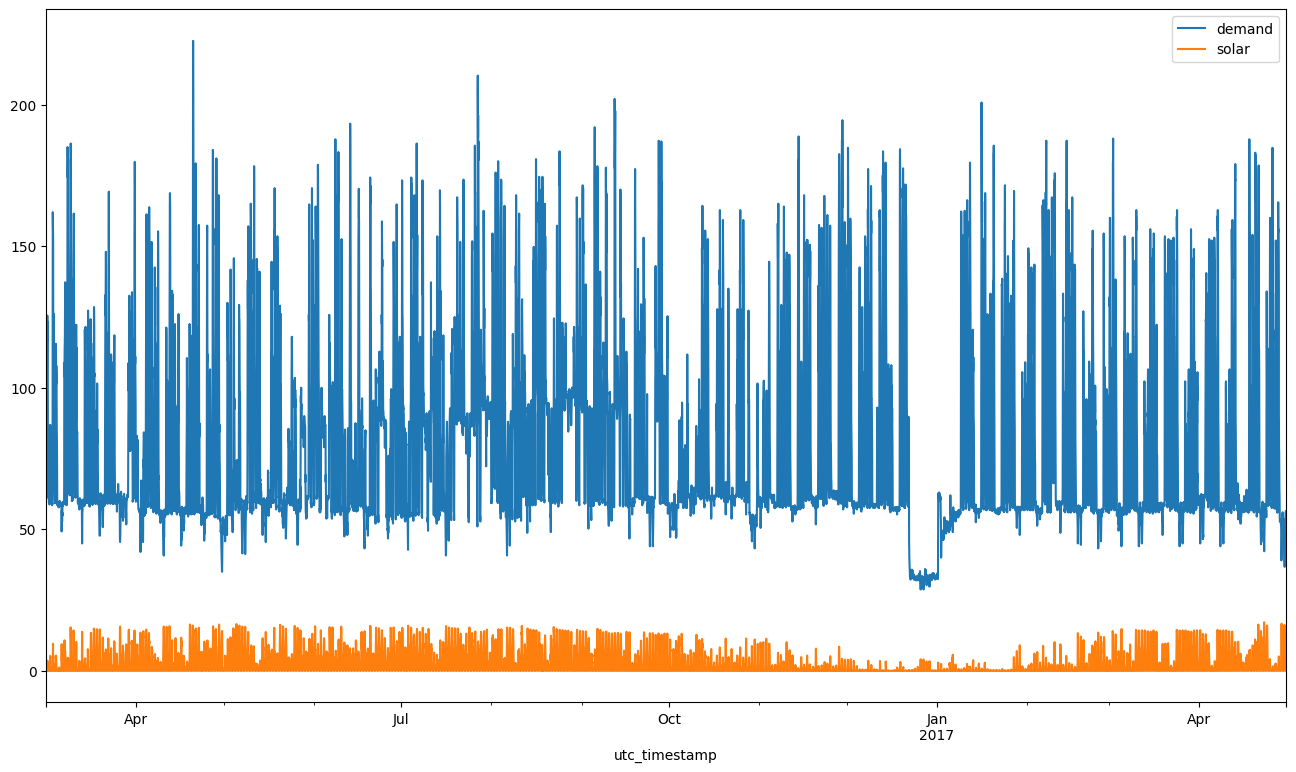

In [9]:
# Use the plot function
data.plot()

 ### <span style="color:#A00000 "> Point out two observations about the given data! </span>

1. < Observation 1 >
2. < Observation 2 >

 ### <span style="color:#A00000 "> Discuss in your group: </span>
 - <span style="color:#A00000 "> What did you find more beneficial, the statistics of the plots? </span>
 - <span style="color:#A00000 "> Do you see a benefit in both statstics and plots or would you only consider one of them? </span>

< Space for your answers>


## Daily observations

This part first shows an example of the pivot table how it is used to plot the data on daily basis. Further it extends by using the month attribute to plot the months in different plots. As you can see differnt days of the month are plotted.

In [10]:
# Calculating the hour of the day the weekday and the day since the beginning of the time series to create the pivot table
data["hour"] = data.index.hour.values
data["weekday"] = data.index.weekday.values
data["month"] = data.index.month.values
data["days_since_start"] = [int(x/(24)) for x in range(0,len(data))]

# creates the pivot table to get a table with the days since start in the columns and hours of the day as rows. For later usage the months are taken into account as the value parameter.
pivot_solar = pd.pivot_table(data, index=['hour'],columns=['days_since_start'], values=['solar','month'])
pivot_solar["solar"]


days_since_start,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
hour,,,,,,,,,,,,,,,,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.084,0.106,0.102,0.124,0.015,0.000,0.023,0.008,0.113,0.223
4,0.000,0.000,0.000,0.006,0.000,0.000,0.002,0.006,0.004,0.000,...,1.463,1.528,1.040,1.672,0.211,0.076,0.117,0.227,0.881,2.054
5,0.000,0.205,0.547,0.681,0.061,0.053,0.502,0.488,0.307,0.224,...,4.247,4.167,3.476,4.354,1.295,0.254,0.733,0.429,2.203,4.730
6,0.031,0.990,1.666,3.859,0.275,0.670,4.348,1.636,1.489,0.840,...,7.392,7.109,4.709,7.243,2.249,0.249,1.369,0.665,4.360,7.585
7,0.089,2.198,3.267,5.347,0.381,3.276,8.972,3.198,1.906,2.103,...,8.559,10.754,7.035,12.203,2.837,0.417,1.566,1.191,11.458,12.461
8,0.275,2.625,7.981,5.131,0.529,9.446,10.793,2.095,4.535,3.266,...,12.472,14.089,11.293,14.811,2.723,0.504,2.604,1.368,15.348,15.247


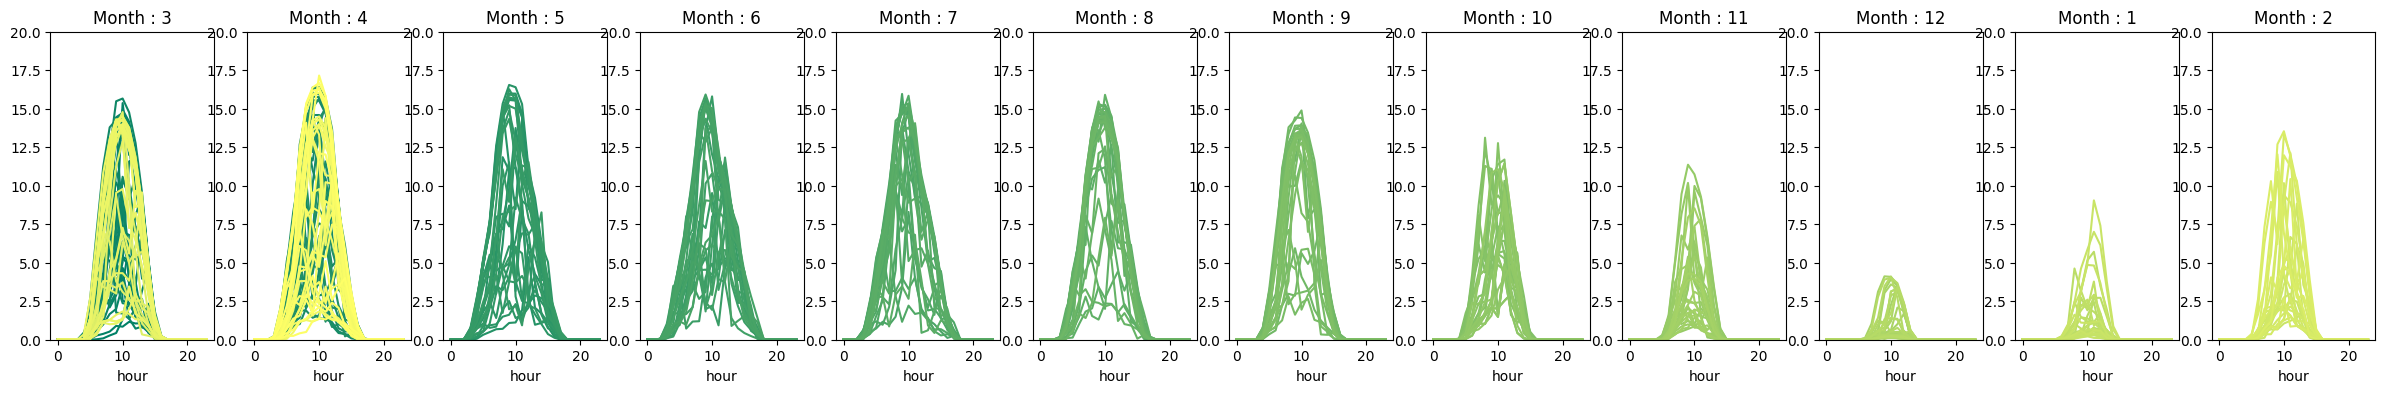

In [11]:
fig, ax = plt.subplots(1,len(data["month"].unique()))
for i in range(len(data["month"].unique())):
    pivot_solar[pivot_solar["month"]==data["month"].unique()[i]]["solar"].plot(ax=ax[i],figsize=(30, 4), layout= (7,1),ylim = (0,20),legend=False, colormap="summer", title="Month : " + str(data["month"].unique()[i]))

 ### <span style="color:#A00000 "> Discuss in your group: </span>
 - <span style="color:#A00000 "> What do you observe during the different months ? </span>

### Workingdays

Explore data Weekday with head and tail and describe.

 ### <span style="color:#A00000 "> Plot only the working days (i.e. Monday-Friday):</span>
 - <span style="color:#A00000 ">The aim is to first filter the data to only get the days from Monday to Friday.</span>
 - <span style="color:#A00000 ">Create a variable ``working_day_data`` and use the weekday column in ``data`` to select the working days. The weekday column is enumerated from 0-6 with 0 being monday and 6 sunday. Therefore working days are the days with a weekday value smaller than five. You can select a column in pandas with ``data["column_name"]`` and if you want to select a subset of the data based on the value in this column you need to use the syntax ``data[data["column_name"] * x]``, where ``*`` indicates a mathematical operater such as ``<`` and ``x`` is the condition. For example, to only select Tuesday you would use ``tuesday_data = data[data["weekday"] == 1]``.</span>
 - <span style="color:#A00000 ">Create the pivot table similar to the example above using the function pivot_table from pandas! [API](https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html). Make sure you use the filtered ``working_day_data`` variable created above.</span>
 - <span style="color:#A00000 ">Extend the pivot table to plot working days. Use "days_since_start" as ``columms``, "hour" as ``index`` and "demand" as ``values``!</span>

Weekdays einzeln ?

<Axes: xlabel='hour'>

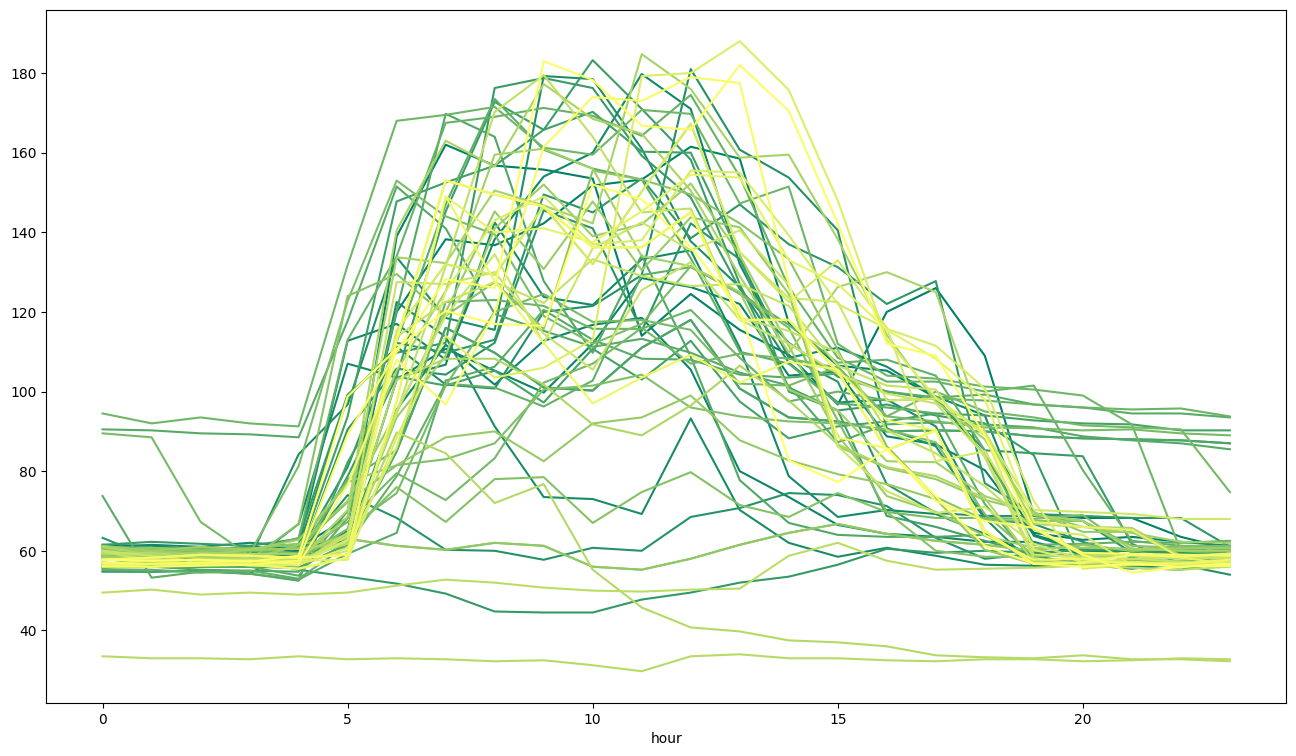

In [12]:

# this get's gapped
working_day_data = data[data["weekday"] == 3]
pivot_workingdays = pd.pivot_table(working_day_data, index=['hour'],columns=['days_since_start'], values=['demand'])

# plots the data
pivot_workingdays["demand"].plot(legend=False,colormap="summer")




### Weekend

 ### <span style="color:#A00000 "> Plot the weekends:</span>
 - <span style="color:#A00000 ">Repeat the task above, but this time only select the weekends (remember weekday is enumerated from 0-6, with 0 being Monday).</span>

<Axes: xlabel='hour'>

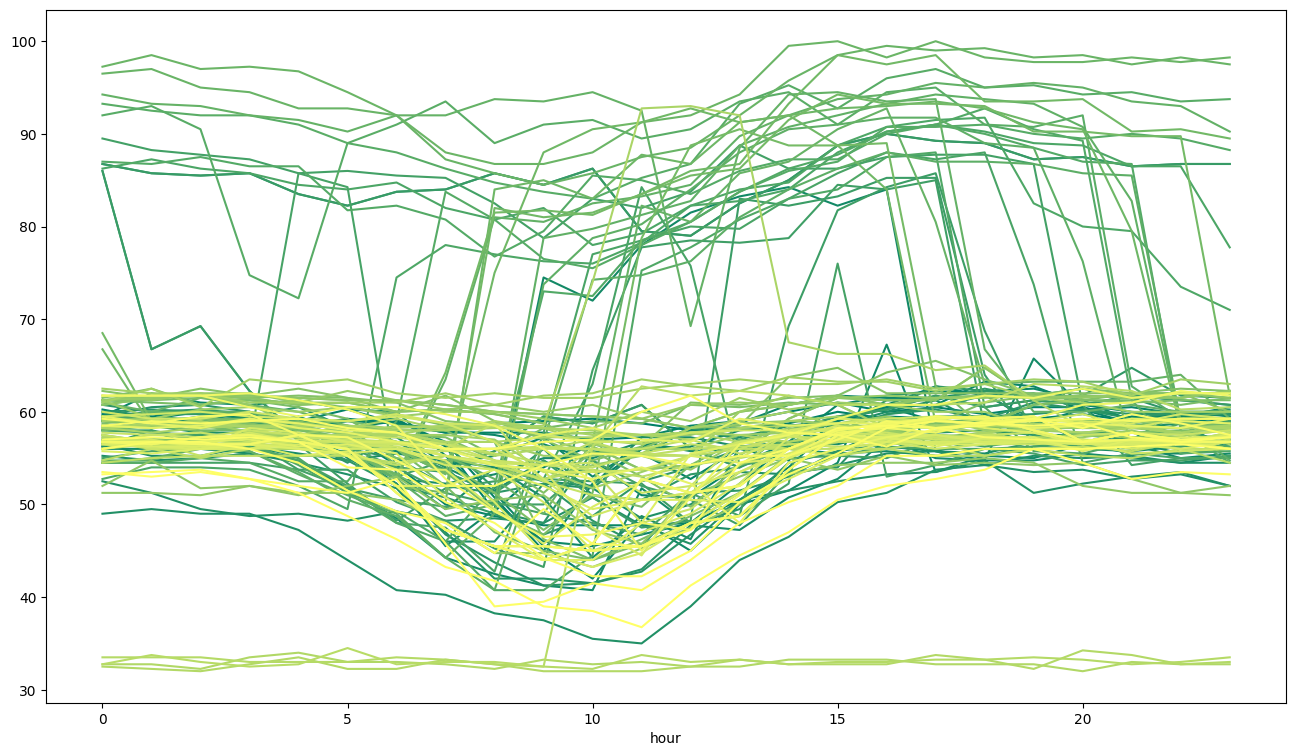

In [13]:

# this get's gapped
weekday_data = data[data["weekday"] >= 5]
pivot_weekends = pd.pivot_table(weekday_data, index=['hour'],columns=['days_since_start'], values=['demand'])
pivot_weekends["demand"].plot(legend=False,colormap="summer")


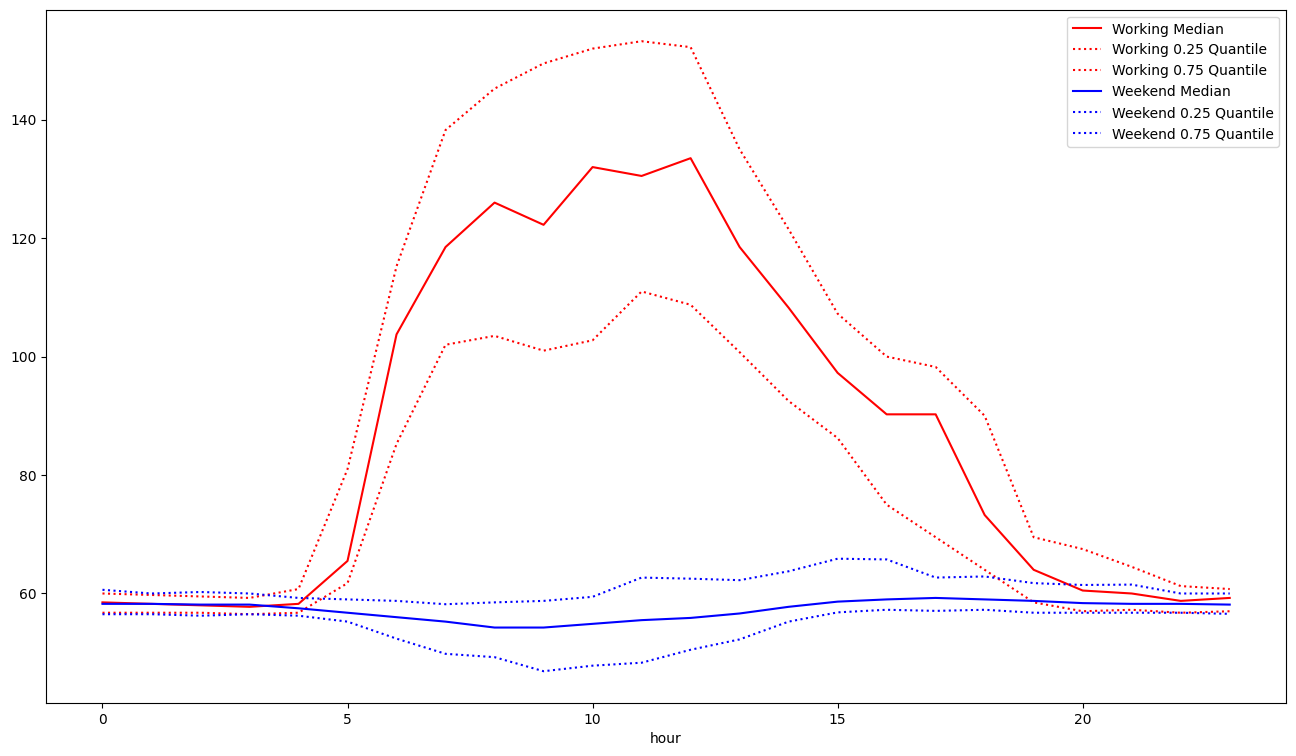

In [14]:
#
# Plot the median of all weekdays
#

pivot_workingdays.median(axis=1).plot(color="red", label="Working Median")
pivot_workingdays.quantile(0.25,axis=1).plot(color="red",linestyle='dotted', label="Working 0.25 Quantile")
pivot_workingdays.quantile(0.75,axis=1).plot(color="red",linestyle='dotted', label="Working 0.75 Quantile")
pivot_weekends.median(axis=1).plot(color="blue", label="Weekend Median")
pivot_weekends.quantile(0.25,axis=1).plot(color="blue",linestyle='dotted', label="Weekend 0.25 Quantile")
pivot_weekends.quantile(0.75,axis=1).plot(color="blue",linestyle='dotted', label="Weekend 0.75 Quantile")
plt.legend()

 ### <span style="color:#A00000 "> Discuss in your group:</span>
 - <span style="color:#A00000 "> Do these different plots (weekdays, weekends, median) fit your expectations?</span>
 - <span style="color:#A00000 "> What could explain the pattern for this building for a weekday? </span>
 - <span style="color:#A00000 "> Could you interfer the base load of the building by looking at the daily observation plots? </span>
 - <span style="color:#A00000 "> How could explain the higher variance of weekdays in contrast to weekends? </span>
 - <span style="color:#A00000 "> Based on these observations, what features would you consider extracting or engineering for a forecasting task? </span>

< Space for your answers>


## Autorcorrelation Function and Seasonal Decomposition

### Autocorrelation Function Plot


The autocorrelation function (ACF) is a statistical technique that we can use to identify how correlated the values in a time series are with each other. The ACF plots the correlation coefficient against the lag, which is measured in terms of a number of periods or units. [Explanation from here](https://www.baeldung.com/cs/acf-pacf-plots-arma-modeling#:~:text=The%20autocorrelation%20function%20(ACF)%20is,number%20of%20periods%20or%20units.)

An detailed expleanation is here: [Autocorrelation](https://support.minitab.com/en-us/minitab/21/help-and-how-to/statistical-modeling/time-series/how-to/autocorrelation/interpret-the-results/autocorrelation-function-acf/)

API-Statsmodels [API](https://www.statsmodels.org/devel/generated/statsmodels.tsa.stattools.acf.html)

### Bonus Statistics: Seasonal Decomposition

An detailed explaination about the used seasonal decomposition can be found here: [API](https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.seasonal_decompose.html)

The additive model which is used here is defined as $Y[t] = T[t] + S[t] + e[t]$.

The results are obtained by first estimating the trend by applying a convolution filter to the data. The trend is then removed from the series and the average of this de-trended series for each period is the returned seasonal component.

#### Demand ACF

 ### <span style="color:#A00000 "> Play around with autocorrelation: </span>
- <span style="color:#A00000 "> Use the ``sm.tsa.graphics.plot_acf(x, lags=None)`` function to plot the autocorrelation function of ``data["demand"]``. </span>
- <span style="color:#A00000 "> Play around with a different number of lags, i.e. 5, 24, 200. </span>
- <span style="color:#A00000 "> What do you observe? </span>

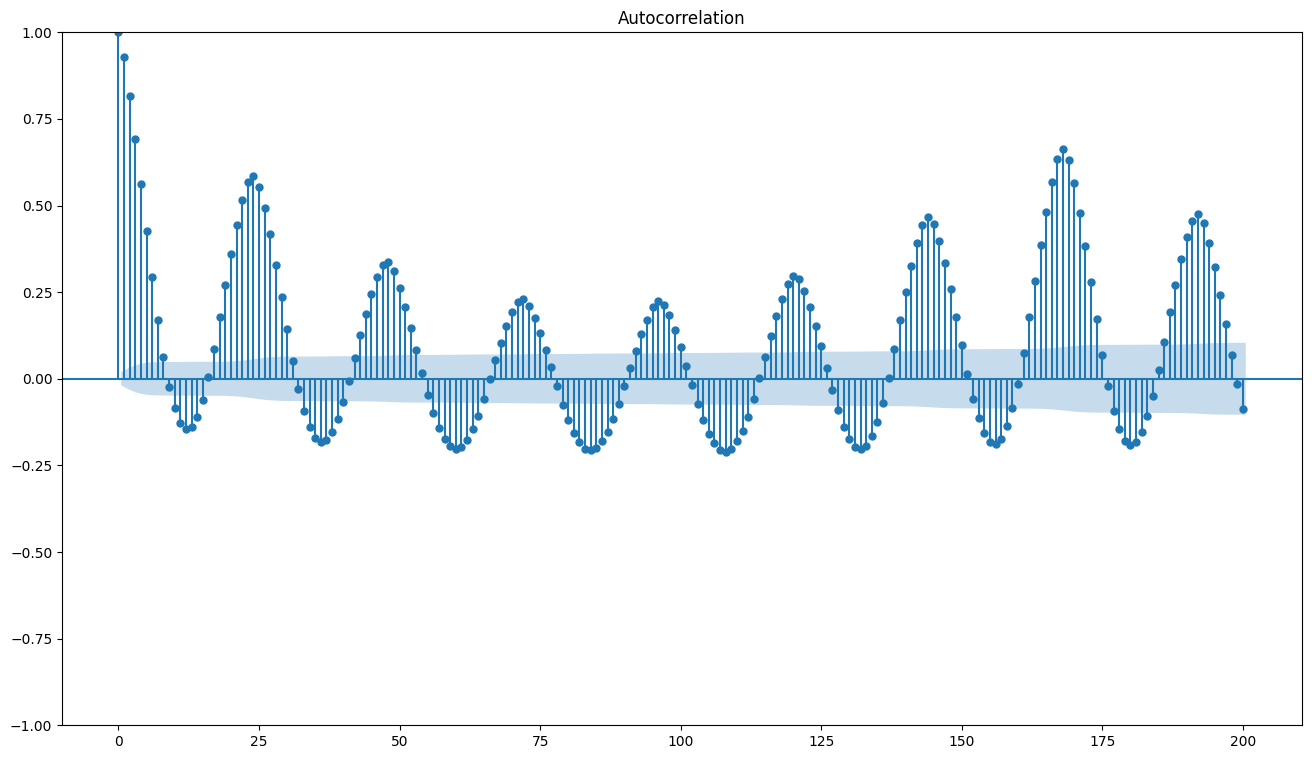

In [15]:
sm.tsa.graphics.plot_acf(data["demand"], lags= 200);

### ACF Solar

 ### <span style="color:#A00000 "> Repeat the above two tasks for the solar data! </span>

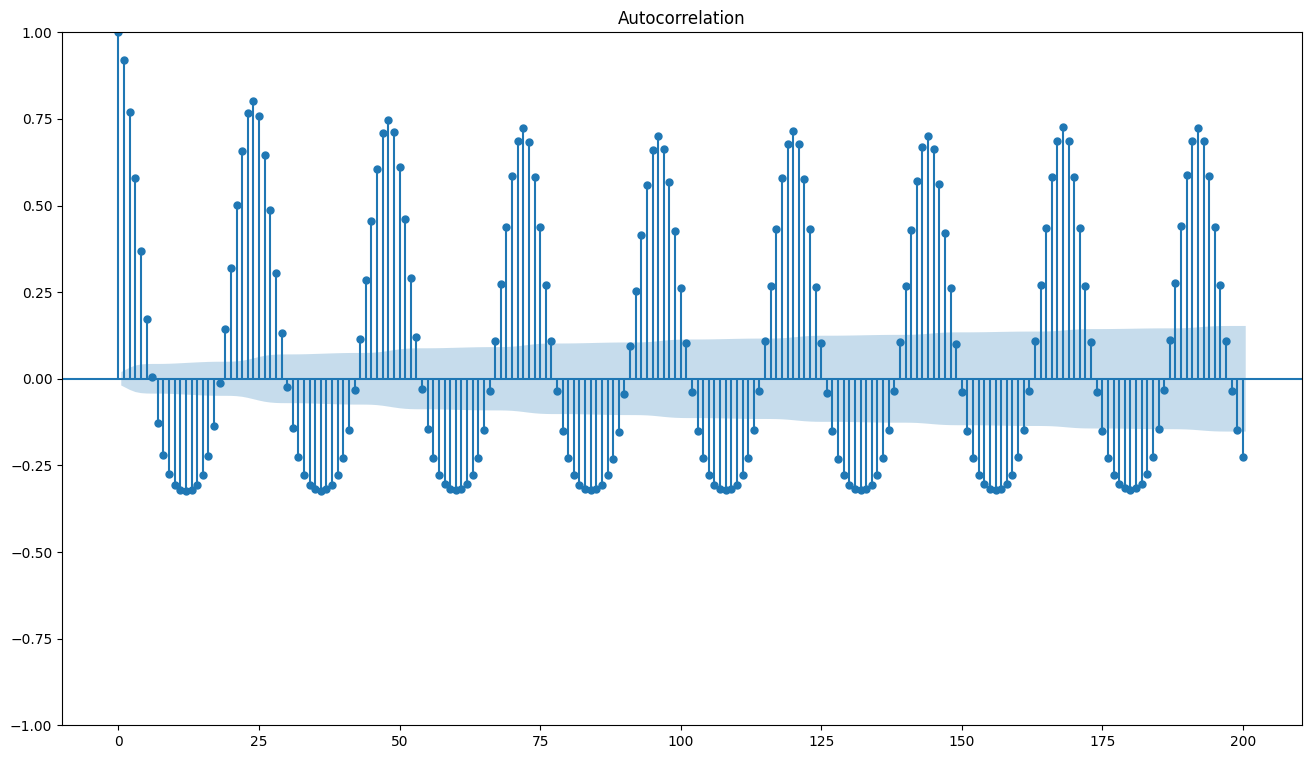

In [16]:
# do seasonale decomposition on solar data (data["solar"])
# Gap here for acf
sm.tsa.graphics.plot_acf(data["solar"], lags= 200);

# <span style="color:#A00000 ">  STOP HERE - We want to discuss some things together before going on </span>

---
# **3. Forecasting Exercise**
---
In this section of the Jupyter Notebook, you will learn how to use **[sktime](https://www.sktime.net/en/stable/)** for time series forecasting.

Time series forecasting is a technique used to predict future values of a variable based on historical data — and optionally known exogenous variables.  
It is widely used in areas such as:

- Finance  
- Economics  
- Engineering  
- **Energy Informatics**

---

## 🔗 Useful Resources

- 📘 **Basic sktime API description:**  
  [sktime API](https://www.sktime.net/en/stable/)

- 🔮 **List of available forecasters:**  
  [Forecaster Overview](https://www.sktime.net/en/stable/estimator_overview.html#filter=all&tags=%7B%7D)

- ⏳ **Forecasting Horizon documentation:**  
  [ForecastingHorizon](https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.forecasting.base.ForecastingHorizon.html)

- 🧩 **ExpandingWindowSplitter:**  
  [ExpandingWindowSplitter](https://www.sktime.net/en/v0.21.0/api_reference/auto_generated/sktime.forecasting.model_selection.ExpandingWindowSplitter.html)

---

## 📊 Time Series Specific - Expanding Window Splitter Illustration

    Fold 1:  *  *  *  *  *  x  x  x  -  -  -
    Fold 2:  *  *  *  *  *  *  x  x  x  -  -
    Fold 3:  *  *  *  *  *  *  *  x  x  x  -
    Fold 4:  *  *  *  *  *  *  *  *  x  x  x
             |  |  |  |  |  |  |  |  |  |  |
    Pos:     1  2  3  4  5  6  7  8  9 10 11

**Legend:**

- `*` → Training window  
- `x` → Forecasting horizon (test window)  
- `-` → Future/unseen data  
- Each row is a fold in cross-validation using an expanding window.
- The training section expands while the test window slides forward.

## 🧪 Exercises

The following exercises will guide you through creating a simple time series forecast using **sktime**.

You will apply a **basic sktime forecasting workflow** to data already introduced in the previous exercise.


## 🔍 Let's Look at What We Prepared

### 📊 Data

We use the data from the previous exercise part.

---

### 📏 Metrics

To evaluate the accuracy of the forecast, this section introduces various metrics such as:

- **Mean Absolute Percentage Error (MAPE)**
- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**

These metrics help you understand how close the forecasted values are to the actual values.

Mathematical definitions:

- $ \text{MAPE} = \frac{1}{n} \sum_{t=1}^{n} \left| \frac{A_t - F_t}{A_t} \right| $
- $ \text{MAE} = \frac{1}{n} \sum_{t=1}^{n} \left| A_t - F_t \right| $
- $ \text{MSE} = \frac{1}{n} \sum_{t=1}^{n} \left( A_t - F_t \right)^2 $

 # <span style="color:#A00000 "> Discuss in Groups</span>
 - <span style="color:#A00000 ">What are the differnt aims of the Metrics/ Loss Functions?</span>





---

### 🤖 Models

We compare three forecasters of increasing complexity:

1. **NaiveForecaster** — classical baseline (e.g. *yesterday's value*).
2. **N-HiTS** — *[Neural Hierarchical Interpolation for Time Series Forecasting](https://arxiv.org/abs/2201.12886)* (Challu et al., 2022): a deep-learning model that has to be **trained** on our data.
3. **Chronos 2** — *[Chronos-2: From univariate to universal forecasting](https://www.amazon.science/blog/introducing-chronos-2-from-univariate-to-universal-forecasting)* (Amazon Science, 2025): a **pre-trained foundation model** for time series that works **zero-shot**, supports **exogenous covariates**, and natively produces **probabilistic forecasts**.


---

### 📈 Visualization

To help interpret the results, we include visualizations that compare **forecasted values** to **actual values** over time.

These visualizations help identify:

- Trends
- Seasonal patterns
- Anomalies or mismatches between forecast and ground truth

---

### ✅ Summary

This section provides a **practical introduction** to using `sktime` for time series forecasting.  
By the end, you will have understood how to:

- Apply a basic forecasting model
- Evaluate its performance using multiple metrics
- Visualize the results for better interpretation


## 📄 Meisenbacher et al. (2022) — Review of Automated Time Series Forecasting Pipelines

Designing a time series forecasting model typically involves five iterative sections:
**data pre-processing**, **feature engineering**, **hyperparameter optimization**,
**forecasting method selection**, and **forecast ensembling**.
As the number of available methods grows, manually tailoring this pipeline to a specific
use case becomes increasingly complex and requires substantial expert knowledge.

Meisenbacher et al. (2022) systematically review existing literature on how each of these
pipeline sections can be automated — covering both AutoML and automated statistical
forecasting approaches. Their analysis shows that most existing work only automates
two or three of the five sections, highlighting the need for holistic pipeline automation.

> *The interactive widget below is inspired by Figure 1 of this paper.*
> *Drag each method card into the correct pipeline section to test your understanding of the forecasting pipeline structure.*

In [17]:
from IPython.display import display, HTML
with open('forecasting_pipeline_widget.html', encoding='utf-8') as f:
    display(HTML(f.read()))

## Start with Forecasting !

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='demand'>)

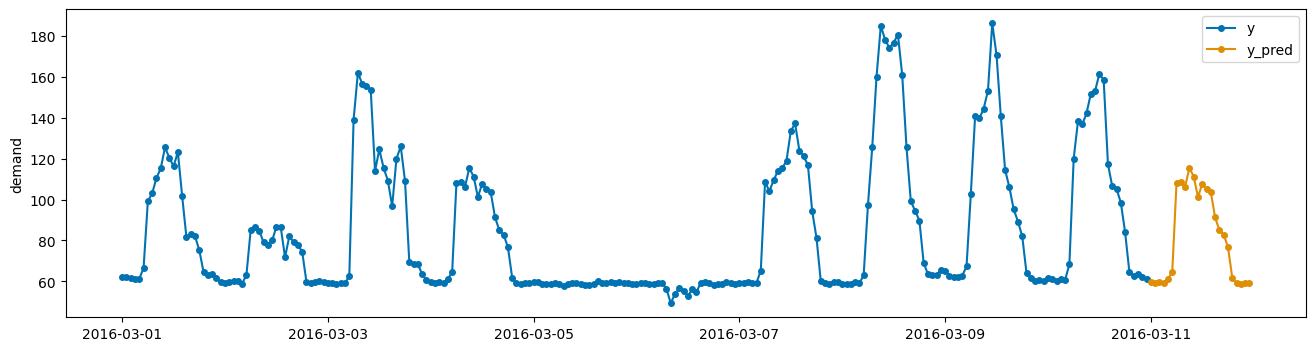

In [18]:
from sklearn.preprocessing import StandardScaler

from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.pytorchforecasting import PytorchForecastingNHiTS
from sktime.forecasting.chronos2 import Chronos2Forecaster

from sktime.utils.plotting import plot_series , plot_windows
from sktime.forecasting.model_evaluation import evaluate
from sktime.split import ExpandingWindowSplitter

from sktime.performance_metrics.forecasting import MeanAbsoluteError , MeanSquaredError , MeanAbsolutePercentageError



#
# Dummy Demonstration How the basic sktime workflow for prediction works within a naive forecaster 
#


# step 1: data specification
y = data["demand"][:24*10] 
# step 2: specifying forecasting horizon
fh = np.arange(1, 25)
# step 3: specifying the forecasting algorithm
forecaster = NaiveForecaster(strategy="last", sp=24*7)
# step 4: fitting the forecaster
forecaster.fit(y)
# step 5: querying predictions
y_pred = forecaster.predict(fh)
# optional: plotting predictions and past data
plot_series(y, y_pred, labels=["y", "y_pred"])


# <span style="color:#A00000 "> Discuss with your group: </span>
- <span style="color:#A00000 "> Discuss what the naiv forecaster does? </span>
- <span style="color:#A00000 "> Why could a navie forecaster could be useful?</span>
- <span style="color:#A00000 "> What is the basic assumption behind a naive forecaster?</span>
- <span style="color:#A00000 "> Where a naive forecaster fails and why?</span>
- <span style="color:#A00000 "> How can other forecaster prevent this?</span>

## Scope Selection & Forecasting

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# SCOPE — Choose here what should be forecast:
#   "demand"   → electricity demand
#   "pv"       → PV generation
#   "residual" → residual load (demand - pv)
# ══════════════════════════════════════════════════════════════════════════════
scope = "demand"   # <-- adjust here

if scope == "demand":
    y = data["demand"]
elif scope == "pv":
    y = data["solar"]
elif scope == "residual":
    y = data["demand"] - data["solar"]
    y.name = "residual"
else:
    raise ValueError(f"Invalid scope: '{scope}'. Choose 'demand', 'pv', or 'residual'.")

print(f"[scope = {scope}]  Length: {len(y)}, Min: {y.min():.2f}, Max: {y.max():.2f}")

[scope = demand]  Length: 10224, Min: 28.75, Max: 222.50


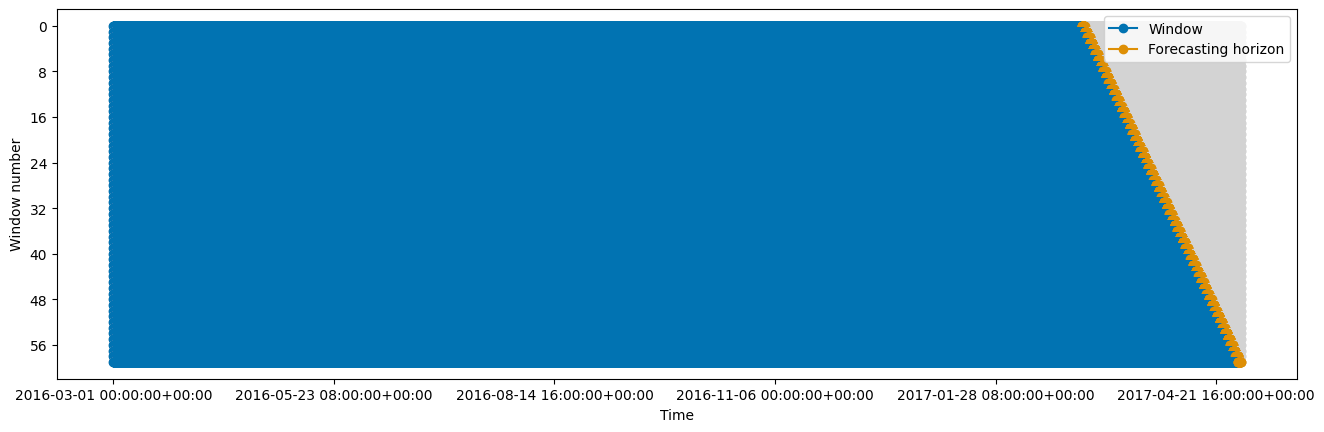

In [20]:
y = data[scope]

TRAINING_LENGTH = 366 * 24 # Because 2016 was a leap year, we use 366 days of hourly data

cv = ExpandingWindowSplitter(
    step_length=24, fh=[i for i in range(1,25)], initial_window=TRAINING_LENGTH
)

plot_windows(cv=cv, y=y)

metrics = [MeanSquaredError(), MeanAbsoluteError(),MeanAbsolutePercentageError()]


In [21]:
# ── CV & Metrics ─────────────────────────────────────────────────────────────
PREDICTION_LENGTH = 24

#── RESULTS DICTIONARY ──────────────────────────────────────────────────────
results_dict = {}

In [22]:
# ── NaiveForecaster ───────────────────────────────────────────────────────────
forecaster_naive = NaiveForecaster(strategy="last", sp=24 * 7)

df_naive = evaluate(
    forecaster=forecaster_naive,
    y=y, cv=cv,
    return_data=True, return_model=False,
    strategy="refit", scoring=metrics,
)
results_dict["NaiveForecaster"] = df_naive

<span style="color:#A00000">

### GET YOUR OWN NHiTS 🤖

- Use `StandardScaler` as a pipeline in combination with NHiTS using the `*` operator  
- Use the `PytorchForecastingNHiTS()` class and instantiate it with `MODEL_PARAMS`, `TRAINER_PARAMS`, and `DATASET_PARAMS`

</span>

In [23]:
# ── NHiTS ─────────────────────────────────────────────────────────────────────

#
#   NHits Parameters for PytorchForecastingNHiTS
#


MODEL_PARAMS={
        "context_length": 24 * 7 * 4,
        "prediction_length": PREDICTION_LENGTH,
        "hidden_size": 64,
        }

TRAINER_PARAMS={
        "max_epochs": 5,
        "logger": False
    }

DATASET_PARAMS={
        "max_encoder_length": 24 * 7 * 4,  # Context length
        "max_prediction_length": PREDICTION_LENGTH,    # Prediction length
    }

# GAPPED
forecaster_nhits = StandardScaler() * PytorchForecastingNHiTS(
    model_params=MODEL_PARAMS,
    trainer_params=TRAINER_PARAMS,
    dataset_params=DATASET_PARAMS,
)

df_nhits = evaluate(
    forecaster=forecaster_nhits,
    y=y, cv=cv,
    return_data=True, return_model=False,
    strategy="no-update_params", scoring=metrics,
)
results_dict["NHits"] = df_nhits

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type           | Params | Mode 
-----------------------------------------------------------
0 | loss            | QuantileLoss   | 0      | train
1 | logging_metrics | ModuleList     | 0      | train
2 | embeddings      | MultiEmbedding | 0      | tr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
/home/ws/hp5743/.conda/envs/uebung_2025_data_analysis/lib/python3.11/site-packages/sktime/forecasting/base/adapters/_pytorchforecasting.py:627: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _y.fillna(0, inplace=True)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/ws/hp5743/.conda/envs/uebung_2025_data_analysis/lib/python3.11/site-packages/sktime/forecasting/base/adapters/_pytorchforecasting.py:627: FutureWar

In [24]:
# ── Loade Pipeline once ───────────────────────────────────────────────────
from chronos import Chronos2Pipeline
pipeline = Chronos2Pipeline.from_pretrained(
    "s3://autogluon/chronos-2",
    device_map="cuda",   # or "cpu"
)

/home/ws/hp5743/.conda/envs/uebung_2025_data_analysis/lib/python3.11/site-packages/chronos/chronos2/pipeline.py:1181: FutureWarning: Loading s3://autogluon/chronos-2 from CloudFront is deprecated and will be removed in a future version. Please specify a HuggingFace model_id instead. For example: Chronos2Pipeline.from_pretrained("amazon/chronos-2")
  return BaseChronosPipeline.from_pretrained(pretrained_model_name_or_path, *args, **kwargs)


## 📅 Feature Engineering

<span style="color:#A00000">

### IMPLEMENT CYCLIC ENCODING 🔄

- A cyclic feature (e.g. hour of day, day of week) repeats periodically — encode it so that the distance between value `0` and value `max_val` is the same as between any two adjacent values  
- Use `np.sin` and `np.cos` with a full period of `2π`  
- The formula for the angle is: `2π * series / max_val`  
- Return both `sin` and `cos` — one component alone is not sufficient to uniquely identify a position in the cycle

</span>

In [25]:
def cyclic_encode(series, max_val):
    # 1) Compute the angle: scale series to one full revolution (0 → 2π)
    angle = 2 * np.pi * series / max_val

    # 2) Apply sine to the angle — captures the "vertical" position in the cycle
    sin = np.sin(angle)

    # 3) Apply cosine to the angle — captures the "horizontal" position in the cycle
    cos = np.cos(angle)

    # return sin, cos
    return sin, cos

In [26]:
from helper_methods import EncodingFeatureBuilder

encodings = EncodingFeatureBuilder(
    y=y,
    cv=cv,
    prediction_length=PREDICTION_LENGTH,
    cyclic_encode_fn=cyclic_encode,   # your implementation
).build()

X_full        = encodings["X_full"]
X_onehot_full = encodings["X_onehot"]
X_target_full = encodings["X_target"]
X_cyclic_full = encodings["X_cyclic"]
X_scaled_full = encodings["X_scaled"]

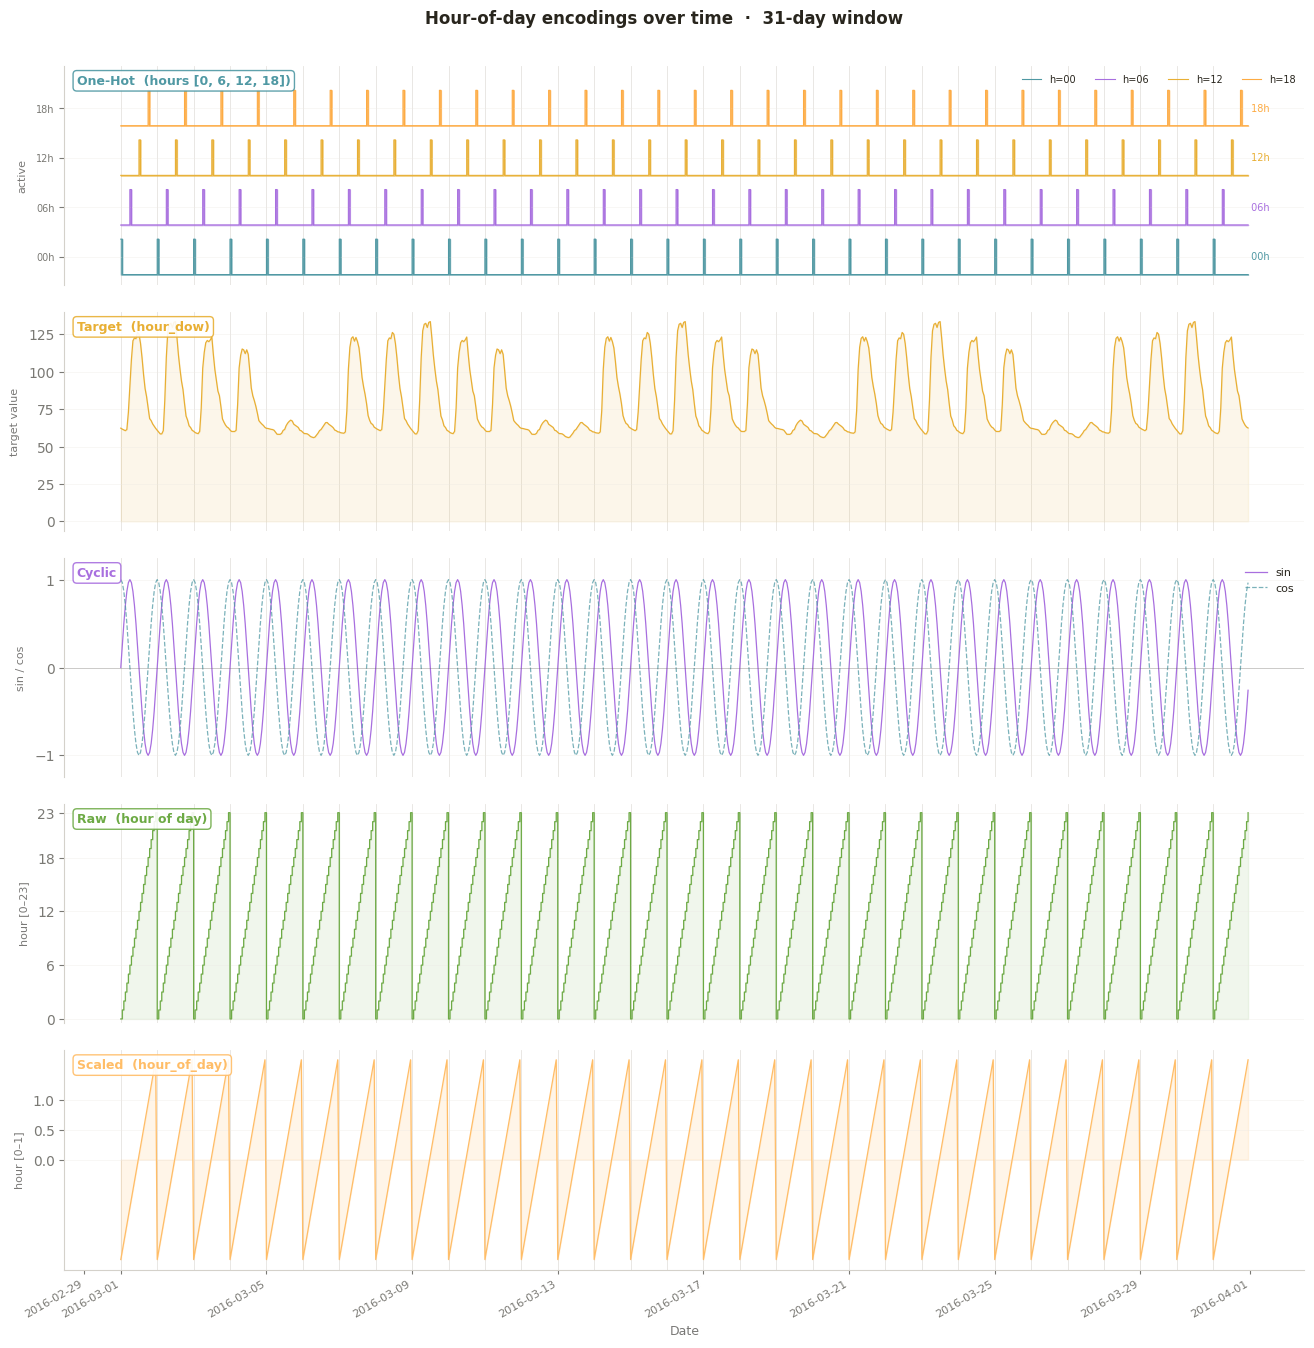

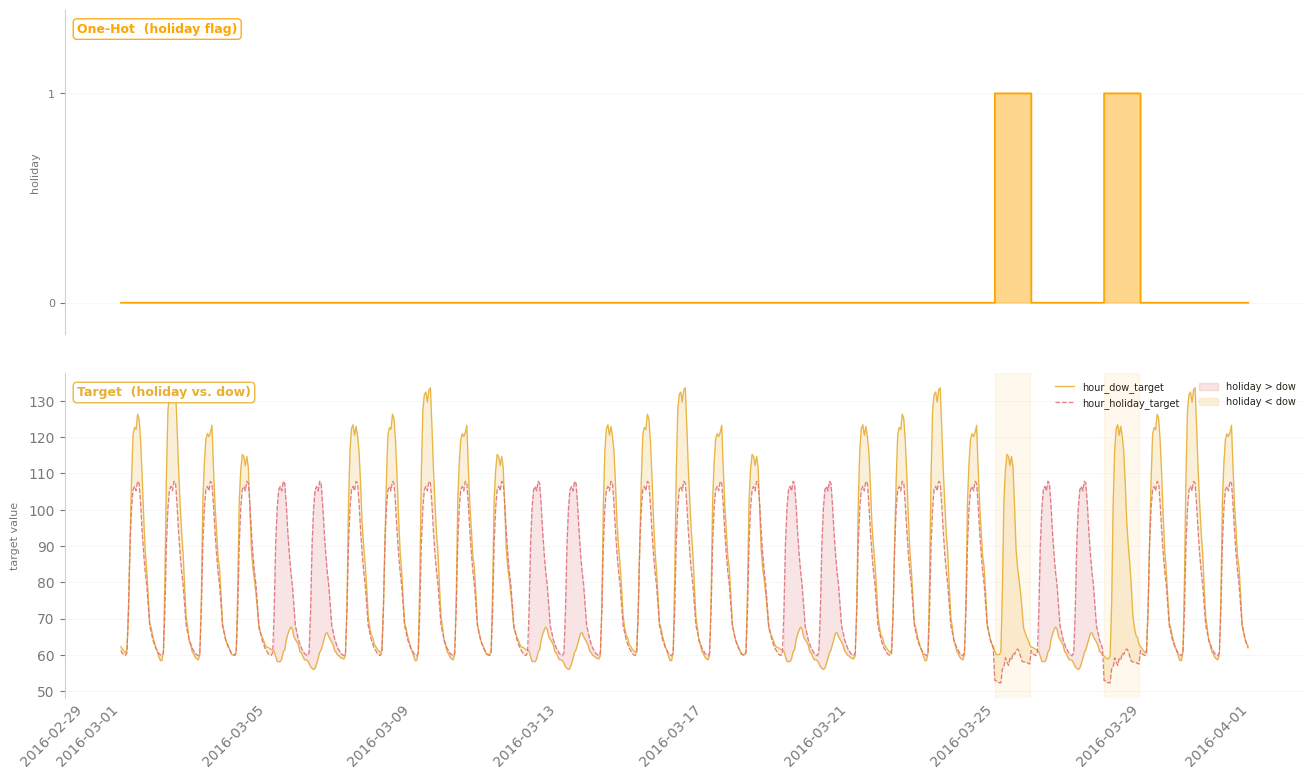

In [27]:



# Hour — binary fills für ausgewählte Stunden
plot_hour_encodings_over_time(
    X_onehot_full, X_target_full, X_cyclic_full, X_scaled_full, X_full,
    sample_days=31, onehot_hours=[0, 6, 12, 18],
)

# Holiday
plot_holiday_encodings_over_time(
    X_onehot_full, X_target_full, X_cyclic_full, X_scaled_full, X_full,
    sample_days=31,
);

### Chronos 2 application

In [28]:
# ── Chronos2 evaluation for all encoding variants ────────────────────────────
ENCODING_VARIANTS = {
    "Chronos2 One-Hot Enc.":       X_onehot_full.loc[y.index],
    "Chronos2 Target Enc.":        X_target_full[["hour_dow_target", "hour_holiday_target"]].loc[y.index],
    "Chronos2 Cyclic Enc.":        X_cyclic_full.loc[y.index],
    "Chronos2 Ordinary Enc.":      X_full.loc[y.index],
    "Chronos2 Scaled Ordinary Enc.": X_scaled_full.loc[y.index],
}

for label, X_cov in ENCODING_VARIANTS.items():
    results_dict[label] = evaluate_chronos2_native(
        y=y, X_covariates=X_cov, cv=cv, pipeline=pipeline,
        prediction_length=PREDICTION_LENGTH,
        label=label.replace("Chronos2 ", "").replace(" Enc.", ""),
    )

# ── Zero-shot baseline (no covariates) ───────────────────────────────────────
results_dict["Chronos2 ZS"] = evaluate_chronos2_native(
    y=y, X_covariates=X_scaled_full.loc[y.index], cv=cv, pipeline=pipeline,
    prediction_length=PREDICTION_LENGTH,
    use_covariates=False, label="ZS",
)

In [ ]:
# ── NHiTS evaluation for all encoding variants ───────────────────────────────
NHITS_VARIANTS = {
    "NHits One-Hot Enc.":            X_onehot_full,
    "NHits Target Enc.":             X_target_full[["hour_dow_target", "hour_holiday_target"]],
    "NHits Cyclic Enc.":             X_cyclic_full,
    "NHits Ordinary Enc.":           X_full,
    "NHits Scaled Ordinary Enc.":    X_scaled_full,
}

for label, X_enc in NHITS_VARIANTS.items():
    forecaster = StandardScaler() * PytorchForecastingNHiTS(
        model_params=MODEL_PARAMS,
        trainer_params=TRAINER_PARAMS,
        dataset_params=DATASET_PARAMS,
    )
    results_dict[label] = evaluate(
        forecaster=forecaster,
        y=y, X=X_enc, cv=cv,
        return_data=True,
        strategy="no-update_params", scoring=metrics, return_model=True,
    )

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type           | Params | Mode 
-----------------------------------------------------------
0 | loss            | QuantileLoss   | 0      | train
1 | logging_metrics | ModuleList     | 0      | train
2 | embeddings      | MultiEmbedding | 0      | train
3 | model           | NHiTS          | 4.2 M  | train
-----------------------------------------------------------
4.2 M     Trainable params
0         Non-trainable params
4.2 M     Total params
16.887    Total estimated model params size (MB)
38        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
/home/ws/hp5743/.conda/envs/uebung_2025_data_analysis/lib/python3.11/site-packages/sktime/forecasting/base/adapters/_pytorchforecasting.py:627: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _y.fillna(0, inplace=True)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/ws/hp5743/.conda/envs/uebung_2025_data_analysis/lib/python3.11/site-packages/sktime/forecasting/base/adapters/_pytorchforecasting.py:627: FutureWar

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# ── Overview ─────────────────────────────────────────────────────────────────
print(f"\n── Encoding comparison  [scope = {scope}] ──")
display(summarize_metrics(results_dict, prefix="test_"))

## Final Probabilistic Evaluation

<span style="color:#A00000">

### Discuss in your group 🤖

- Execute the next cell!
- How well did the model perform?  
- Were the results as expected?

</span>


In [ ]:
# filtered results_dicts
chronos_results_dict = {k: v for k, v in results_dict.items() if "Chronos2" in k}
print(f"\n── Chronos2 Enc. comparison  [scope = {scope}] ──")
display(summarize_metrics(chronos_results_dict, prefix="test_"))   

nhits_results_dict = {k: v for k, v in results_dict.items() if "NHits" in k}
print(f"\n── NHits Enc. comparison  [scope = {scope}] ──")
display(summarize_metrics(nhits_results_dict, prefix="test_"))

results_dict.keys()

In [ ]:
plot_full_forecast_series(chronos_results_dict)

In [ ]:
models_dict = {
    name: df.rename(columns={"forecast": "y_pred", "actual": "y_test"})
    for name, df in results_dict.items()
}

group_baselines = {k: models_dict[k] for k in [
    "NaiveForecaster",
    "NHits",
    "Chronos2 ZS",
]}

# Group 2: Chronos2 — Enc.
group_chronos = {k: models_dict[k] for k in [
    "Chronos2 One-Hot Enc.",
    "Chronos2 Target Enc.",
    "Chronos2 Cyclic Enc.",
    "Chronos2 Ordinary Enc.",
    "Chronos2 Scaled Ordinary Enc.",
]}

# Group 3: NHits — Enc.
group_nhits = {k: models_dict[k] for k in [
    "NHits One-Hot Enc.",
    "NHits Target Enc.",
    "NHits Cyclic Enc.",
    "NHits Ordinary Enc.",
    "NHits Scaled Ordinary Enc.",
]}



interactive_forecast_plot(
    group_chronos,
    y=y,                        
    X_full=X_full,             
    X_target_full=X_target_full,
    X_cyclic_full=X_cyclic_full,
    X_scaled_full=X_scaled_full,
    context_hours=24 * 7 * 4 * 4,
)

---

# **4. Probabilistic Forecasting**
---

It is often desirable to not only produce a point forecast, but also to estimate the uncertainty of the forecast.

### 📊 What is a Probabilistic Forecast?

A **probabilistic forecast** provides a **range of possible future values**, not just a single prediction.

---

#### 🔹 Point Forecast (Standard):
Predicts only one value per time step.  
*Example:*  
> Tomorrow's sales will be **100 units**.

---

#### 🔹 Probabilistic Forecast:
Gives multiple quantiles or intervals, showing the **uncertainty** around the prediction.  
*Example:*  
> There's a 90% chance that tomorrow's sales will be **between 85 and 120 units**.

---

### ✅ Why Use It?

- Captures **uncertainty** in your forecasts
- Supports **risk-aware decision making**
- Essential for **planning in unpredictable environments**

---



<span style="color:#A00000">

# Instruction: Create a Probabilistic Forecast

Use the `evaluate` function to generate a probabilistic forecast with the trained model. Make sure to set the scoring to a probabilistic metric, e.g. PinballLoss.  
Use the exogenous features `X` as input.  

</span>


In [ ]:
# Insert NHITS here because the Chronos interface does not provide this in sktime yet

from sktime.performance_metrics.forecasting.probabilistic import PinballLoss
# Quantiles
quantiles = [0.1, 0.5, 0.9]  # 10%, 50%, and 90% quantiles

loss = PinballLoss(alpha=quantiles)
result_dict_prob = {}

# Use evaluate with the pinball loss
forecaster_nhits = StandardScaler() * PytorchForecastingNHiTS(
    model_params=MODEL_PARAMS,
    trainer_params=TRAINER_PARAMS,
    dataset_params=DATASET_PARAMS
)

import sys
import os

# Redirect stderr to /dev/null
stderr_orig = sys.stderr
sys.stderr = open(os.devnull, 'w')

# deine evaluate() calls hier

# Danach wiederherstellen!
#sys.stderr = stderr_orig
df_nhits_prob = evaluate(
    forecaster=forecaster_nhits,
    X=X_full,
    y=y,
    cv=cv,
    return_data=True,
    return_model=True,
    strategy="no-update_params",
    scoring=loss,
)
result_dict_prob["NHits"] = df_nhits_prob

## Probabilistic Evaluation

<span style="color:#A00000">

### Discuss in your group 🤖

- Execute the next cell!
- How well did the model perform?  
- Were the results as expected?

</span>


In [ ]:
plot_full_forecast_series_prob(result_dict_prob)

---

# **Thank you for your attention!**

--- 
## <span style="color:#A00000 "> Now you can play! </span>
- <span style="color:#A00000 "> Play around with the forecast horizon and the number of historical features.</span>
- <span style="color:#A00000 "> You can also try changing the scope variable being forecast.</span>
- <span style="color:#A00000 "> How do the results change?</span>
- <span style="color:#A00000 "> Which forecasters perform best?</span>

<img src="https://imgs.xkcd.com/comics/machine_learning.png" width="600" height="800">

[This xkcd comic you can find here](https://xkcd.com/1838/)
